<a href="https://colab.research.google.com/github/PutriBalqisAfradinata/PutriBalqisAfradinata_2411531009_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Library

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

2. Load Dataset

In [4]:
# load dataset
dataset_url = "https://raw.githubusercontent.com/PutriBalqisAfradinata/PutriBalqisAfradinata_2411531009_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv"
df = pd.read_csv(dataset_url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


3. Split Data Training dan Testing

In [5]:
# pisahkan fitur dan target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=16
)

### MODEL 1 — Logistic Regression Tanpa Scaling

Train **Model**

In [7]:
model_no_scaling = LogisticRegression(max_iter=5000)

model_no_scaling.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

Prediksi

In [8]:
y_pred_no_scaling = model_no_scaling.predict(X_test)

Hitung Accuracy

In [9]:
accuracy_no_scaling = accuracy_score(y_test, y_pred_no_scaling)
print("Accuracy tanpa scaling:", accuracy_no_scaling)

Accuracy tanpa scaling: 0.9005847953216374


Confusion Matrix

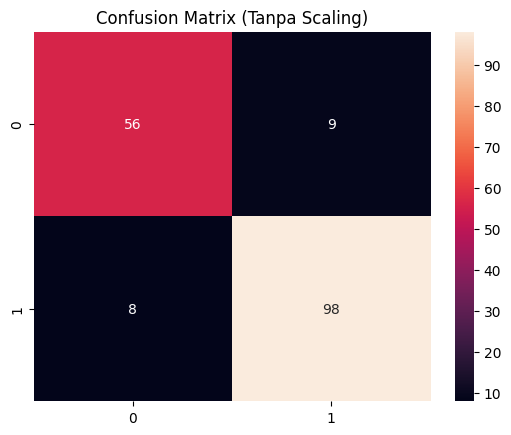

In [10]:
cm_no_scaling = confusion_matrix(y_test, y_pred_no_scaling)

sns.heatmap(cm_no_scaling, annot=True, fmt='d')
plt.title("Confusion Matrix (Tanpa Scaling)")
plt.show()

Classification Report

In [11]:
print(classification_report(y_test, y_pred_no_scaling))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87        65
           1       0.92      0.92      0.92       106

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



## MODEL 2 — Logistic Regression DENGAN Scaling

Scaling Data

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Model

In [14]:
model_scaling = LogisticRegression(max_iter=5000)

model_scaling.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

Prediksi

In [15]:
y_pred_scaling = model_scaling.predict(X_test_scaled)

Accuracy

In [16]:
accuracy_scaling = accuracy_score(y_test, y_pred_scaling)

print("Accuracy dengan scaling:", accuracy_scaling)

Accuracy dengan scaling: 0.9415204678362573


Confusion Matrix

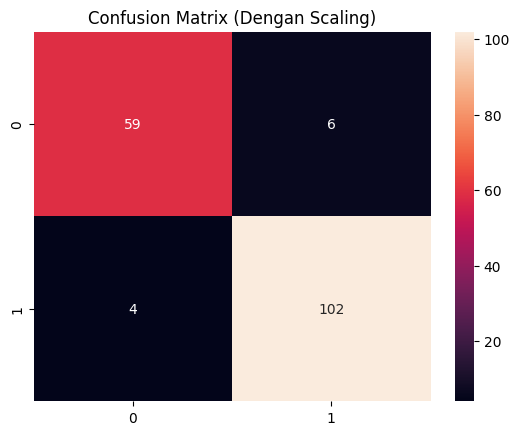

In [17]:
cm_scaling = confusion_matrix(y_test, y_pred_scaling)

sns.heatmap(cm_scaling, annot=True, fmt='d')
plt.title("Confusion Matrix (Dengan Scaling)")
plt.show()

Classification Report

In [18]:
print(classification_report(y_test, y_pred_scaling))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92        65
           1       0.94      0.96      0.95       106

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



## Bandingkan Hasil Scaling dan Tanpa Scaling

In [19]:
print("Perbandingan Model")

print("Accuracy tanpa scaling:", accuracy_no_scaling)
print("Accuracy dengan scaling:", accuracy_scaling)

Perbandingan Model
Accuracy tanpa scaling: 0.9005847953216374
Accuracy dengan scaling: 0.9415204678362573


Percobaan Threshold

In [20]:
y_prob = model_scaling.predict_proba(X_test_scaled)[:,1]

Threshold 0.3

In [21]:
threshold = 0.3
y_pred_03 = (y_prob >= threshold).astype(int)

print("Accuracy threshold 0.3:", accuracy_score(y_test, y_pred_03))

Accuracy threshold 0.3: 0.935672514619883


Threshold 0.5

In [22]:
threshold = 0.5
y_pred_05 = (y_prob >= threshold).astype(int)

print("Accuracy threshold 0.5:", accuracy_score(y_test, y_pred_05))

Accuracy threshold 0.5: 0.9415204678362573


Threshold 0.7

In [23]:
threshold = 0.7
y_pred_07 = (y_prob >= threshold).astype(int)

print("Accuracy threshold 0.7:", accuracy_score(y_test, y_pred_07))

Accuracy threshold 0.7: 0.9122807017543859


ROC Curve

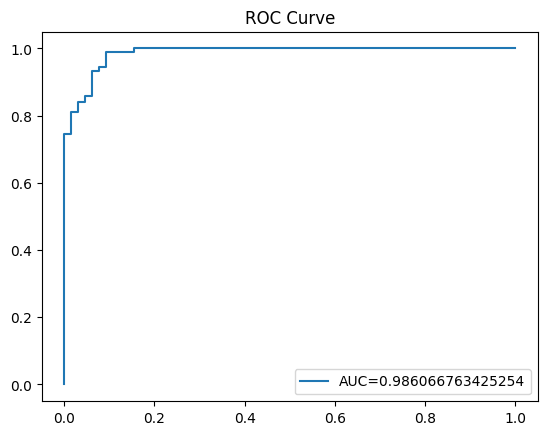

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC="+str(auc))
plt.legend()
plt.title("ROC Curve")
plt.show()

## === ANALISIS ===

**Perbandingan Scaling**

Model dengan scaling menghasilkan performa yang lebih stabil karena fitur memiliki skala yang sama sehingga proses optimasi Logistic Regression menjadi lebih efektif.



**Pengaruh Threshold**

Perubahan nilai threshold mempengaruhi sensitivitas model dalam melakukan klasifikasi. Threshold yang lebih rendah meningkatkan jumlah prediksi positif sedangkan threshold yang lebih tinggi membuat model lebih selektif dalam memprediksi kelas positif.